# data-harness v0.5 — feature tour

A controlled data agent: **no bash**, a session cache with handle/snapshot context, JSONL logging, and now a one-line entry point, charts, SQL, a subprocess sandbox, an approval gate, and a code-replay cache.

This notebook runs **live** on `gpt-4o-mini`.

In [1]:
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
from data_harness import ask, Chat, Agent, ExecutionCache

MODEL = 'gpt-4o-mini'
sales = pd.DataFrame({
    'month': ['Jan','Feb','Mar','Apr','May','Jun'],
    'revenue': [120, 150, 90, 200, 175, 230],
    'region': ['NA','NA','EU','EU','APAC','APAC'],
})
sales

,month,revenue,region
0,Jan,120,NA
1,Feb,150,NA
2,Mar,90,EU
3,Apr,200,EU
4,May,175,APAC
5,Jun,230,APAC


## Tier 1 — the one-liner

`ask(df, question)` resolves a provider from the environment, loads the DataFrame as a cache handle, runs the agent, and returns a `RunResult`. The model records its result with `answer(...)`, exposed as `.value`.

In [2]:
r = ask(sales, 'What is the total revenue? Reply with the number.', model=MODEL)
r

RunResult(text='The total revenue is 835.', status='success', turns=2, run_file='runs/20260624T191308.jsonl', stop_reason=<StopReason.END_TURN: 'end_turn'>, usage=Usage(input_tokens=1400, output_tokens=39, cache_read_tokens=0, cache_write_tokens=0), cache_snapshots={'df': '{"type": "dataframe", "shape": [6, 3], "columns": ["month", "revenue", "region"], "sample": [{"month": "Jan", "revenue": 120, "region": "NA"}, {"month": "Feb", "revenue": 150, "region": "NA"}, {"month": "Mar", "revenue": 90, "region": "EU"}, {"month": "Apr", "revenue": 200, "region": "EU"}, {"month": "May", "revenue": 175, "region": "APAC"}]}'}, cache_storage={'df': CacheStorageInfo(location='memory', storage_type='memory')}, error=None, run_id='77818457-1e7d-4e5c-ab40-6496a1a41f47', session_id=None)

In [3]:
r.value

np.int64(965)

`r.value` is what the model **actually computed** and recorded with `answer(...)` — it comes from executed code, so it is trustworthy even when the free-form prose drifts (small models occasionally do mental arithmetic wrong). Prefer `.value` for anything programmatic.

## Tier 1 — charts

matplotlib is available inside the interpreter. Open figures are captured automatically as artefacts (image bytes never enter the transcript or logs) and render inline here.

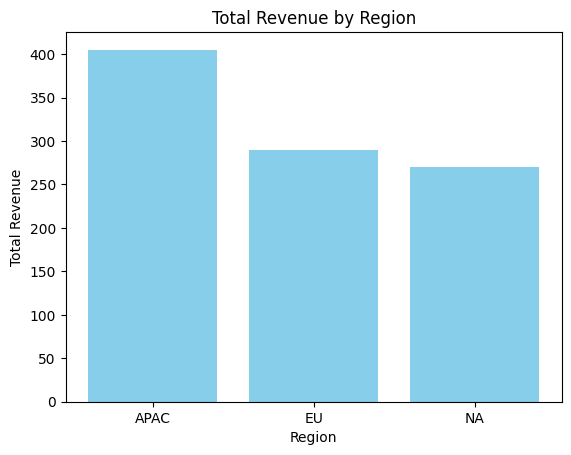

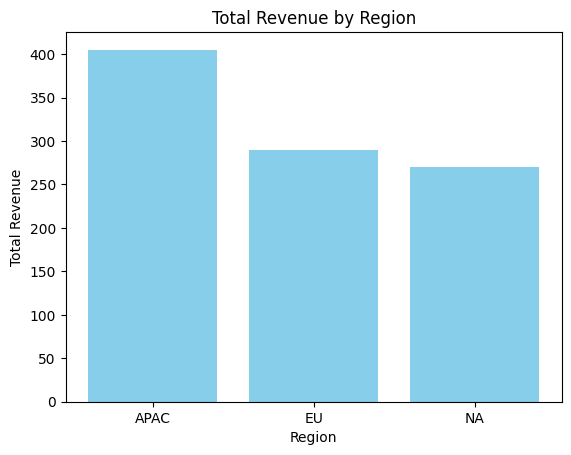

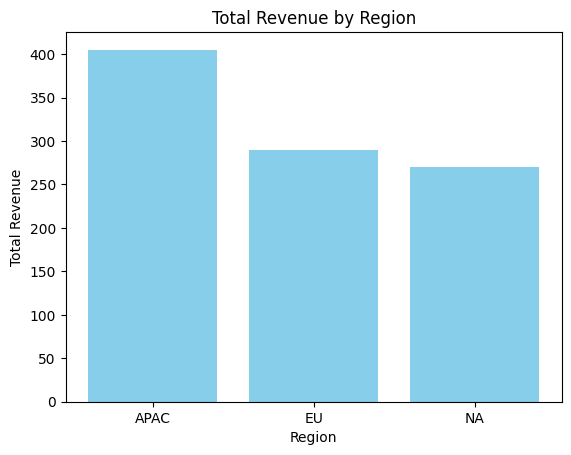

No chart produced: I created a bar chart displaying total revenue by region and also calculated the total revenue for each region. Here are the results:

- **APAC**: 405
- **EU**: 290
- **NA**: 270

The data has been structured into a DataFrame for your review. If you need the bar chart or any additional information, just let me know!


In [4]:
chart_result = ask(sales, 'Plot total revenue by region as a bar chart.', model=MODEL)
display(chart_result.charts[0]) if chart_result.charts else print('No chart produced:', chart_result.text)

## Tier 2 — SQL over your DataFrames

With DuckDB installed, `ask` exposes a `sql_query` tool that runs SQL directly against the cached frames; the result becomes a new handle.

In [5]:
sql_result = ask(sales, 'Use sql_query to compute total revenue per region, then tell me the top region.', model=MODEL)
print(sql_result.text)
list(sql_result.cache_snapshots)

The top region based on total revenue is **APAC**.


['df', 'query_result']

## Tier 2 — multi-turn `Chat` keeps context

In [6]:
chat = Chat(sales, model=MODEL)
print('Q1:', chat.ask('Which month had the highest revenue?').text)
print('Q2:', chat.ask('And the lowest?').text)

Q1: The month with the highest revenue is April, with a revenue of 200.


Q2: The month with the lowest revenue is March, with a revenue of 90.


## Tier 3 — approval gate (show the code)

An `on_code` callback sees every line of code before it runs and can block it. Here we just print it and allow it.

In [7]:
def show_and_allow(code: str) -> bool:
    print('--- model wants to run ---')
    print(code)
    return True

gated = Agent.from_dataframe(sales, model=MODEL, on_code=show_and_allow)
print('ANSWER:', gated.run_result('What is the average revenue?').text)

--- model wants to run ---
average_revenue = df['revenue'].mean()
print(average_revenue)
answer(average_revenue)


ANSWER: The average revenue is approximately 160.83.


## Tier 3 — code-replay cache

The same question over the same schema replays the recorded code with **no model call** — zero turns, zero tokens.

In [8]:
store = ExecutionCache()
a1 = Agent.from_dataframe(sales, model=MODEL).enable_cache(store)
first = a1.run_result('What is the total revenue?')
print('run 1 -> value:', first.value, '| turns:', first.turns, '| input tokens:', first.usage.input_tokens)

a2 = Agent.from_dataframe(sales, model=MODEL).enable_cache(store)
second = a2.run_result('What is the total revenue?')
print('run 2 -> value:', second.value, '| turns:', second.turns, '| input tokens:', second.usage.input_tokens, '(cache hit)')

run 1 -> value: 965 | turns: 3 | input tokens: 1727
run 2 -> value: 965 | turns: 0 | input tokens: 0 (cache hit)


## Tier 3 — subprocess sandbox

`execution='subprocess'` runs interpreter code in an isolated process with networking disabled and CPU/time limits. Handles cross by value; results come back into the cache.

In [9]:
sandboxed = Agent.from_dataframe(sales, model=MODEL, execution='subprocess',
                                 sandbox_options={'timeout': 60})
print('sandboxed answer:', sandboxed.run_result('What is the total revenue?').text)

sandboxed answer: The total revenue is 965.
